# Object Oriented Programming (OOP): Creating a Financial Instrument Class

## An example Class: pandas.DataFrame
Goal: handling and manipulating any Tabular Data (efficiently)

In [27]:
import pandas as pd

__Instantiation__

In [28]:
df = pd.read_csv(r"C:\Users\bedla\Documents\Ausbildung_Informatik\1_Praktikum\Praktikum_Daten-_und_Prozessanalyse\energy_trading\PyCharm_Notebook\Data\titanic.csv")

In [29]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
0,0,3,male,22.0,1,0,7.2500,S,NaN
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,S,NaN
3,1,1,female,35.0,1,0,53.1000,S,C
4,0,3,male,35.0,0,0,8.0500,S,NaN
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,NaN
887,1,1,female,19.0,0,0,30.0000,S,B
888,0,3,female,NaN,1,2,23.4500,S,NaN
889,1,1,male,26.0,0,0,30.0000,C,C


In [30]:
type(df)

pandas.core.frame.DataFrame

__Attributes__

In [31]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'deck'],
      dtype='object')

In [32]:
df.shape

(891, 9)

__Methods__

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   deck      203 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [34]:
df.sort_values(by = "age", ascending = False)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
630,1,1,male,80.0,0,0,30.0000,S,A
851,0,3,male,74.0,0,0,7.7750,S,NaN
493,0,1,male,71.0,0,0,49.5042,C,NaN
96,0,1,male,71.0,0,0,34.6542,C,A
116,0,3,male,70.5,0,0,7.7500,Q,NaN
...,...,...,...,...,...,...,...,...,...
859,0,3,male,NaN,0,0,7.2292,C,NaN
863,0,3,female,NaN,8,2,69.5500,S,NaN
868,0,3,male,NaN,0,0,9.5000,S,NaN
878,0,3,male,NaN,0,0,7.8958,S,NaN


## The FinancialInstrument Class live in action (Part 1)
Goal: Analyzing Financial Instruments (e.g. stocks) efficiently

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
plt.style.use("seaborn-v0_8")

Note: you need __yfinance version 0.2.48 or higher__.

Check your currently installed version:

In [36]:
yf.__version__

'0.2.66'

You can upgrade with:

pip install --upgrade yfinance

In [37]:
class FinancialInstrument():
    ''' Klasse zur Analyse von Finanzinstrumenten wie Aktien.

    Attribute
    ==========
    ticker: str
        Tickersymbol, mit dem gearbeitet werden soll
    start: str
        Startdatum für die Datenabfrage
    end: str
        Enddatum für die Datenabfrage

    Methoden
    =======
    get_data:
        ruft tägliche Kursdaten (von Yahoo Finance) ab und bereitet die Daten auf
    log_returns:
        berechnet Log-Renditen
    plot_prices:
        erstellt ein Kursdiagramm
    plot_returns:
        stellt Log-Renditen entweder als Zeitreihe („ts”) oder Histogramm („hist”) dar
    set_ticker:
        legt einen neuen Ticker fest
mean_return:
        berechnet die mittlere Rendite
std_returns:
        berechnet die Standardabweichung der Renditen (Risiko)
annualized_perf:
        berechnet die annualisierte Rendite und das annualisierte Risiko
    '''
    
    def __init__(self, ticker, start, end):
        self.ticker = ticker
        self.start = start
        self.end = end
        self.get_data()
        self.log_returns()
    
    def __repr__(self): 
        return "FinancialInstrument(ticker = {}, start = {}, end = {})".format(self.ticker, 
                                                                               self.start, self.end)
    def get_data(self):
        ''' retrieves (from yahoo finance) and prepares the data
        '''
        raw = yf.download(self.ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
        raw.rename(columns = {"Close":"price"}, inplace = True)
        self.data = raw
        
    def log_returns(self):
        '''calculates log returns
        '''
        self.data["log_returns"] = np.log(self.data.price/self.data.price.shift(1))
        
    def plot_prices(self):
        ''' creates a price chart
        '''
        self.data.price.plot(figsize = (12, 8))
        plt.title("Price Chart: {}".format(self.ticker), fontsize = 15)
    
    def plot_returns(self, kind = "ts"):
        ''' plots log returns either as time series ("ts") or histogram ("hist")
        '''
        if kind == "ts":
            self.data.log_returns.plot(figsize = (12, 8))
            plt.title("Returns: {}".format(self.ticker), fontsize = 15)
        elif kind == "hist":
            self.data.log_returns.hist(figsize = (12, 8), bins = int(np.sqrt(len(self.data))))
            plt.title("Frequency of Returns: {}".format(self.ticker), fontsize = 15)
    
    def set_ticker(self, ticker = None):
        '''sets a new ticker
        '''
        if ticker is not None:
            self.ticker = ticker
            self.get_data()
            self.log_returns()
            
    def mean_return(self, freq = None):
        '''calculates mean return
        '''
        if freq is None:
            return self.data.log_returns.mean()
        else:
            resampled_price = self.data.price.resample(freq).last()
            resampled_returns = np.log(resampled_price / resampled_price.shift(1))
            return resampled_returns.mean()
    
    def std_returns(self, freq = None):
        '''calculates the standard deviation of returns (risk)
        '''
        if freq is None:
            return self.data.log_returns.std()
        else:
            resampled_price = self.data.price.resample(freq).last()
            resampled_returns = np.log(resampled_price / resampled_price.shift(1))
            return resampled_returns.std()
        
    def annualized_perf(self):
        '''calculates annulized return and risk
        '''
        mean_return = round(self.data.log_returns.mean() * 252, 3)
        risk = round(self.data.log_returns.std() * np.sqrt(252), 3)
        print("Return: {} | Risk: {}".format(mean_return, risk))

__Instantiation__

In [38]:
stock = FinancialInstrument(ticker = "AAPL", start = "2015-01-01", 
                            end =  "2019-12-31") # instantiation

C:\Users\bedla\AppData\Local\Temp\ipykernel_14036\3909387290.py:46: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(self.ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: CertificateVerifyError('Failed to perform, curl: (60) SSL certificate problem: self signed certificate in certificate chain. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


In [39]:
stock

FinancialInstrument(ticker = AAPL, start = 2015-01-01, end = 2019-12-31)

In [40]:
type(stock)

__main__.FinancialInstrument

__Attributes__

In [41]:
#stock.

In [42]:
stock.ticker

'AAPL'

In [43]:
stock.start

'2015-01-01'

In [44]:
stock.end

'2019-12-31'

In [45]:
stock.data

,price,log_returns
Date,,


__Methods__

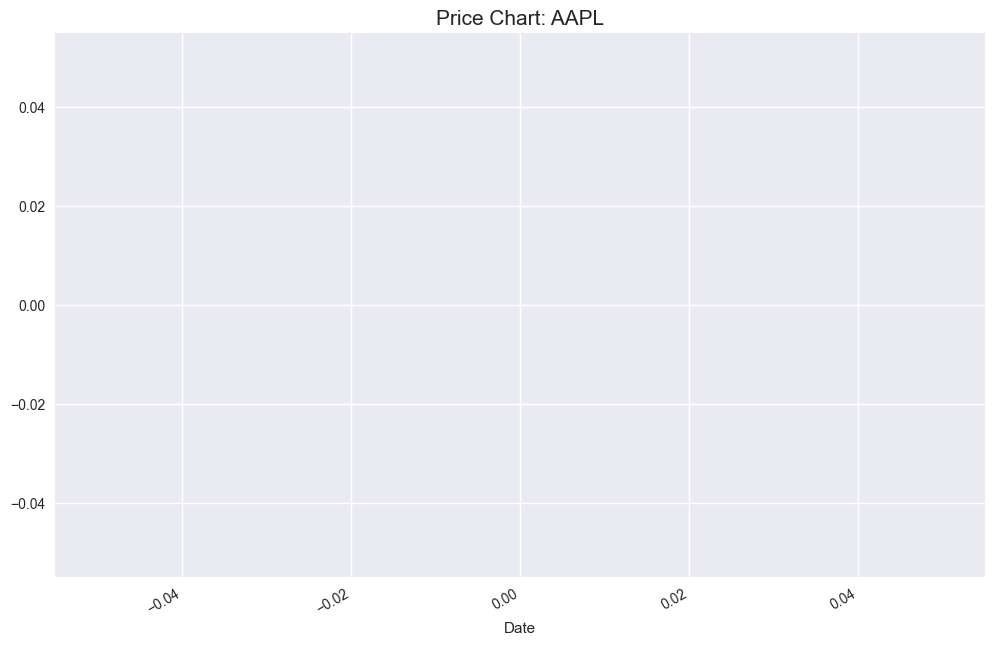

In [46]:
stock.plot_prices()

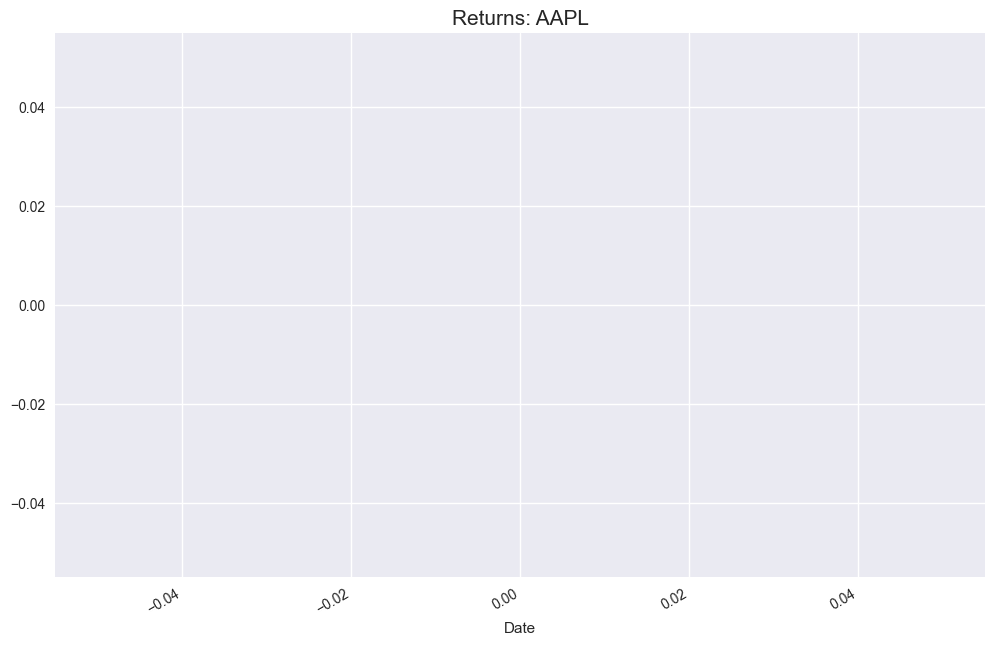

In [47]:
stock.plot_returns()

ValueError: `bins` must be positive, when an integer

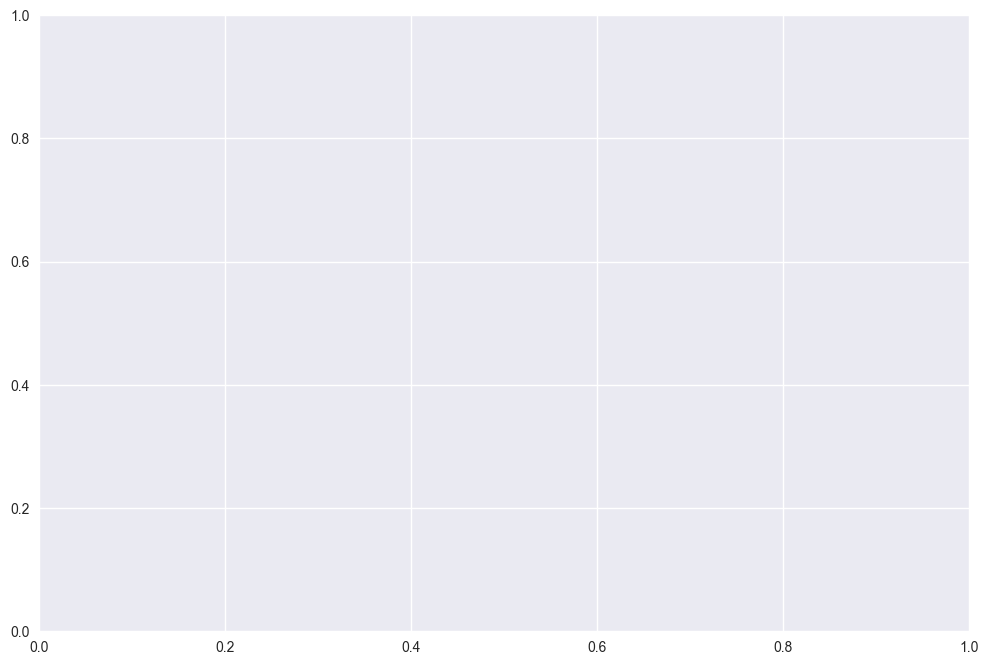

In [48]:
stock.plot_returns(kind = "hist")

## The FinancialInstrument Class live in action (Part 2)

__More Methods__

In [49]:
stock.mean_return()

nan

In [50]:
stock.data.log_returns.mean()

nan

In [52]:
stock.mean_return(freq = "W") # NEW - replace w by W

nan

In [53]:
stock.std_returns()

nan

In [54]:
stock.std_returns(freq = "W") # NEW - replace w by W

nan

In [55]:
stock.annualized_perf()

Return: nan | Risk: nan


In [56]:
stock.set_ticker("GE")

C:\Users\bedla\AppData\Local\Temp\ipykernel_14036\3909387290.py:46: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(self.ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['GE']: CertificateVerifyError('Failed to perform, curl: (60) SSL certificate problem: self signed certificate in certificate chain. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


In [57]:
stock.ticker

'GE'

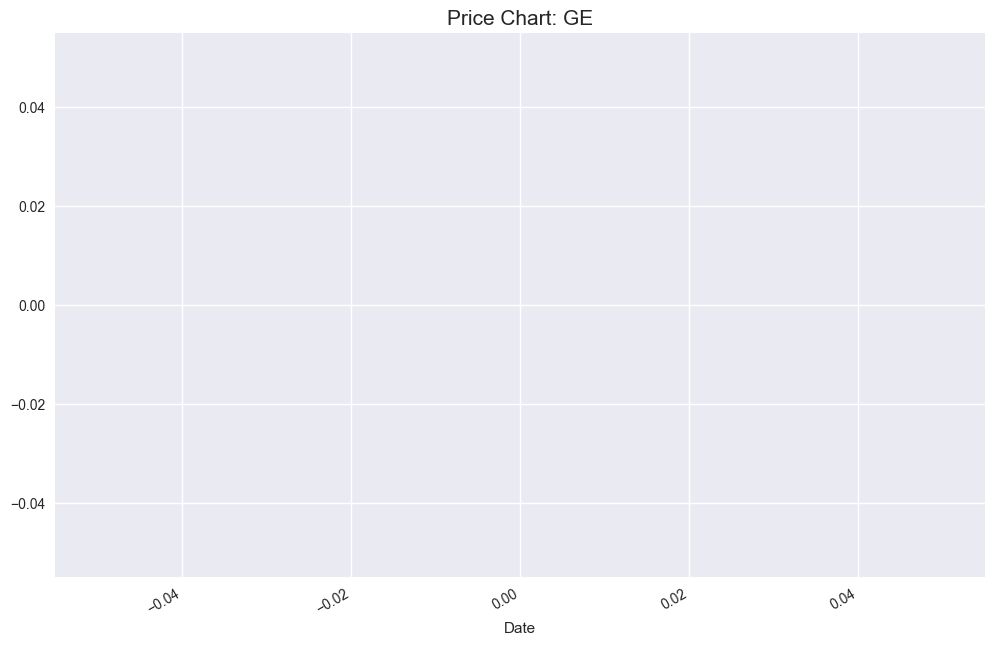

In [58]:
stock.plot_prices()

In [59]:
stock.annualized_perf()

Return: nan | Risk: nan


## Building the FinancialInstrument Class from scratch: Instantiation

In [60]:
class FinancialInstrument():
    pass

In [61]:
stock = FinancialInstrument() # instantiation

In [62]:
stock

In [63]:
class FinancialInstrument():
    def __init__(self, ticker, start, end):
        self.ticker = ticker
        self.start = start
        self.end = end

In [64]:
stock = FinancialInstrument("AAPL", "2015-01-01", "2019-12-31") # instantiation

In [65]:
stock

In [66]:
stock.ticker

'AAPL'

In [67]:
stock.end

'2019-12-31'

In [68]:
stock.start

'2015-01-01'

## The method get_data()

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
plt.style.use("seaborn-v0_8")

In [70]:
# yf.download("AAPL", "2015-01-01", "2019-12-31").Close.to_frame() # old

In [71]:
yf.download("AAPL", "2015-01-01", "2019-12-31", multi_level_index = False,auto_adjust=True).Close.to_frame() # new from yfinance 0.2.48

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: CertificateVerifyError('Failed to perform, curl: (60) SSL certificate problem: self signed certificate in certificate chain. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


,Close
Date,


In [72]:
raw=yf.download("AAPL", "2015-01-01", "2019-12-31", multi_level_index = False,auto_adjust=True).Close.to_frame()

[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: CertificateVerifyError('Failed to perform, curl: (60) SSL certificate problem: self signed certificate in certificate chain. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


In [73]:
raw.rename(columns = {"Close":"price"}, inplace = True)

In [74]:
raw

,price
Date,


In [75]:
class FinancialInstrument():
    def __init__(self, ticker, start, end):
        self.ticker = ticker
        self.start = start
        self.end = end
        self.get_data()
    def get_data(self):
        raw = yf.download(self.ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
        raw.rename(columns = {"Close":"price"}, inplace = True)
        self.data = raw

In [76]:
stock = FinancialInstrument("AAPL", "2015-01-01", "2019-12-31")

C:\Users\bedla\AppData\Local\Temp\ipykernel_14036\156962179.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(self.ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: CertificateVerifyError('Failed to perform, curl: (60) SSL certificate problem: self signed certificate in certificate chain. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


In [77]:
stock.ticker

'AAPL'

In [78]:
stock.data

,price
Date,


## The method log_returns()

In [79]:
stock.data

,price
Date,


In [80]:
class FinancialInstrument():
    def __init__(self, ticker, start, end):
        self.ticker = ticker
        self.start = start
        self.end = end
        self.get_data()
        self.log_returns()
    def get_data(self):
        raw = yf.download(self.ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
        raw.rename(columns = {"Close":"price"}, inplace = True)
        self.data = raw
    def log_returns(self):
        self.data["log_returns"] = np.log(self.data.price/self.data.price.shift(1))

In [81]:
stock = FinancialInstrument("AAPL", "2015-01-01", "2019-12-31")

C:\Users\bedla\AppData\Local\Temp\ipykernel_14036\1644076762.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(self.ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: CertificateVerifyError('Failed to perform, curl: (60) SSL certificate problem: self signed certificate in certificate chain. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


In [82]:
stock.data

,price,log_returns
Date,,


In [83]:
stock.log_returns()

## (String) Representation

In [84]:
stock

In [85]:
print(stock)

In [86]:
class FinancialInstrument():
    def __init__(self, ticker, start, end):
        self.ticker = ticker
        self.start = start
        self.end = end
        self.get_data()
        self.log_returns()
    
    def __repr__(self):
        return "FinancialInstrument(ticker = {}, start = {}, end = {})".format(self.ticker,
                                                                               self.start, self.end)
    def get_data(self):
        raw = yf.download(self.ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
        raw.rename(columns = {"Close":"price"}, inplace = True)
        self.data = raw
        
    def log_returns(self):
        self.data["log_returns"] = np.log(self.data.price/self.data.price.shift(1))

In [87]:
stock = FinancialInstrument("AAPL", "2015-01-01", "2019-12-31")

C:\Users\bedla\AppData\Local\Temp\ipykernel_14036\3880623625.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(self.ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: CertificateVerifyError('Failed to perform, curl: (60) SSL certificate problem: self signed certificate in certificate chain. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


In [88]:
stock

FinancialInstrument(ticker = AAPL, start = 2015-01-01, end = 2019-12-31)

In [89]:
print(stock)

FinancialInstrument(ticker = AAPL, start = 2015-01-01, end = 2019-12-31)


## The methods plot_prices() and plot_returns()

In [90]:
stock

FinancialInstrument(ticker = AAPL, start = 2015-01-01, end = 2019-12-31)

In [91]:
stock.data

,price,log_returns
Date,,


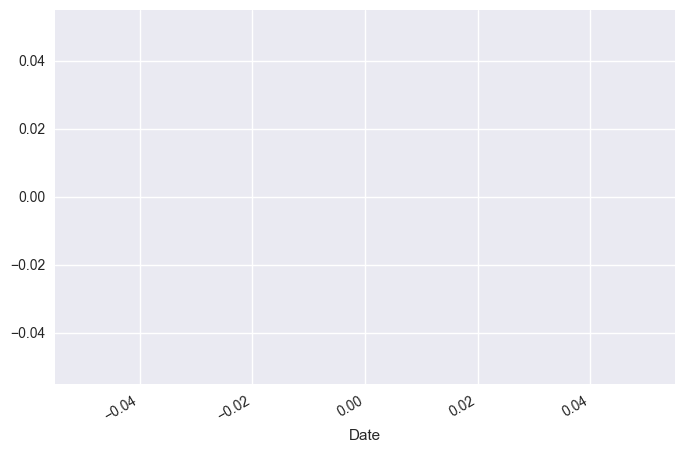

In [92]:
stock.data.price.plot()
plt.show()

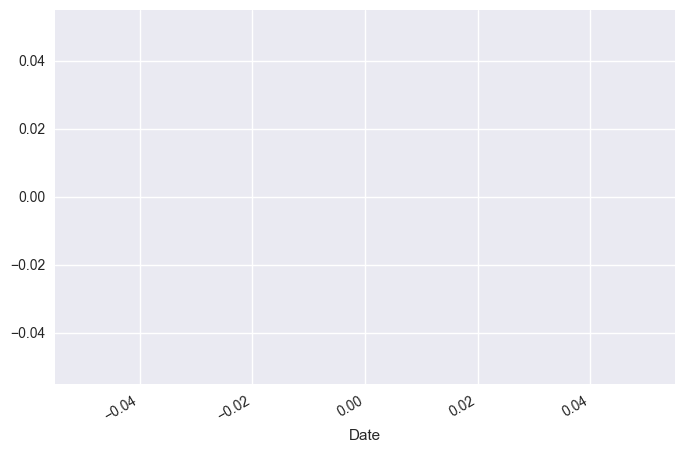

In [93]:
stock.data.log_returns.plot()
plt.show()

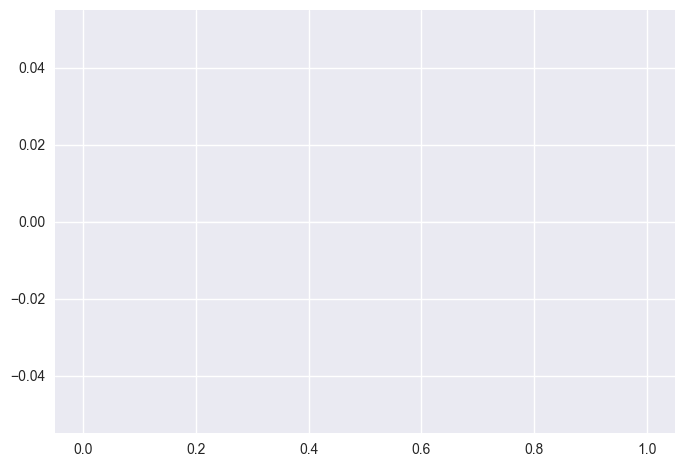

In [94]:
stock.data.log_returns.hist(bins = 100)
plt.show()

In [95]:
class FinancialInstrument():
    def __init__(self, ticker, start, end):
        self.ticker = ticker
        self.start = start
        self.end = end
        self.get_data()
        self.log_returns()
    
    def __repr__(self): 
        return "FinancialInstrument(ticker = {}, start = {}, end = {})".format(self.ticker, 
                                                                               self.start, self.end)
    def get_data(self):
        raw = yf.download(self.ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
        raw.rename(columns = {"Close":"price"}, inplace = True)
        self.data = raw
        
    def log_returns(self):
        self.data["log_returns"] = np.log(self.data.price/self.data.price.shift(1))
        
    def plot_prices(self):
        self.data.price.plot(figsize = (12, 8))
        plt.title("Price Chart: {}".format(self.ticker), fontsize = 15)
    
    def plot_returns(self, kind = "ts"):
        if kind == "ts":
            self.data.log_returns.plot(figsize = (12, 8))
            plt.title("Returns: {}".format(self.ticker), fontsize = 15)
        elif kind == "hist":
            self.data.log_returns.hist(figsize = (12, 8), bins = int(np.sqrt(len(self.data))))
            plt.title("Frequency of Returns: {}".format(self.ticker), fontsize = 15)  

In [96]:
stock = FinancialInstrument("aapl", "2015-01-01", "2019-12-31")

C:\Users\bedla\AppData\Local\Temp\ipykernel_14036\408373132.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(self.ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: CertificateVerifyError('Failed to perform, curl: (60) SSL certificate problem: self signed certificate in certificate chain. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


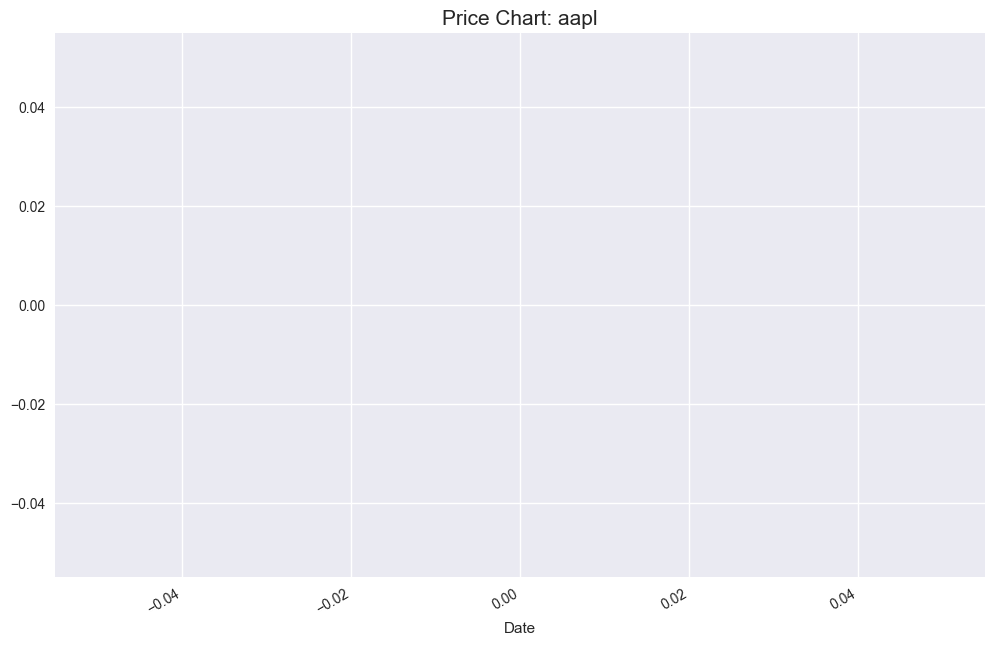

In [97]:
stock.plot_prices()

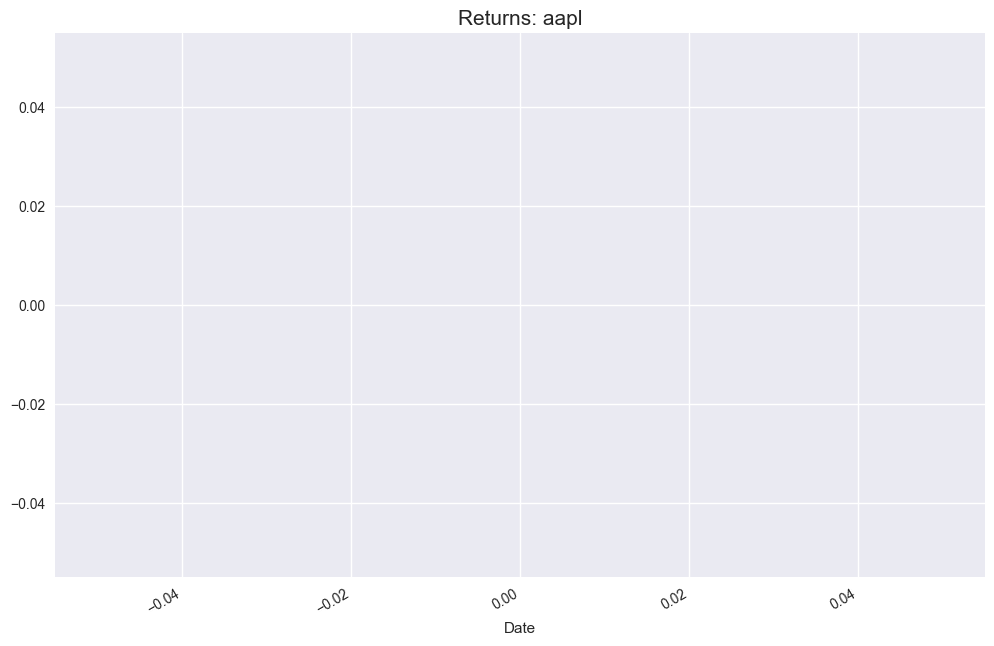

In [98]:
stock.plot_returns()

ValueError: `bins` must be positive, when an integer

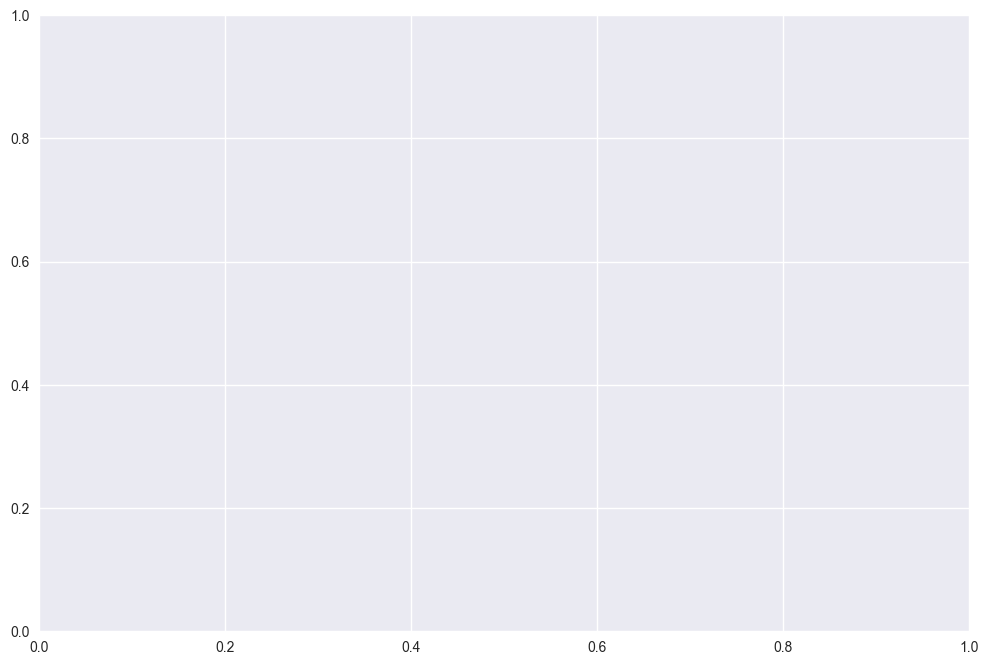

In [99]:
stock.plot_returns(kind = "hist")

## Encapsulation

In [102]:
stock

FinancialInstrument(ticker = aapl, start = 2015-01-01, end = 2019-12-31)

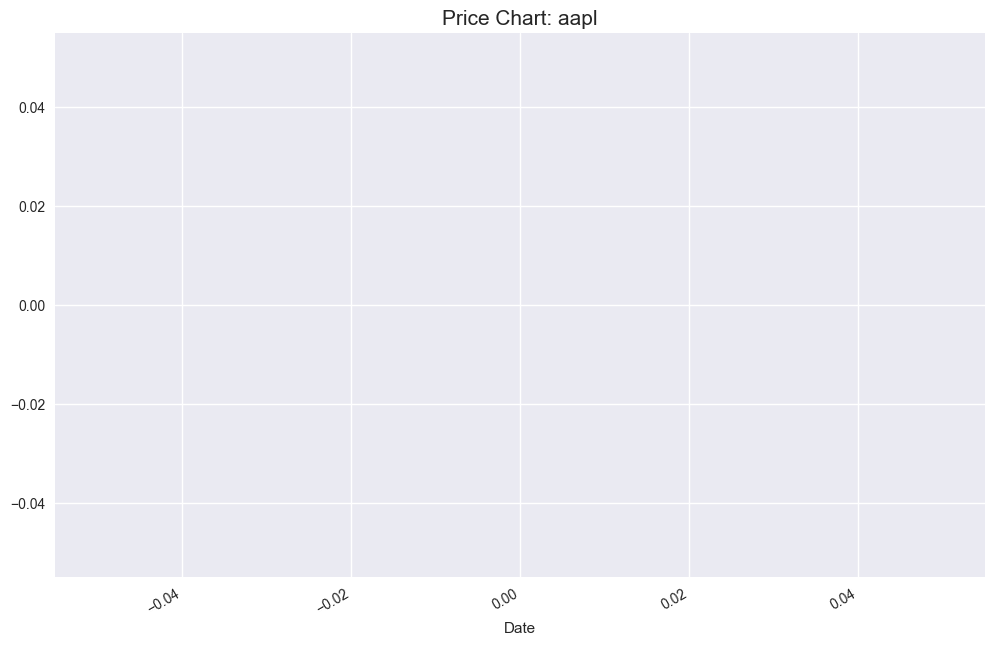

In [103]:
stock.plot_prices()

In [104]:
stock.ticker

'aapl'

In [105]:
stock.ticker = "GE"

In [106]:
stock.ticker

'GE'

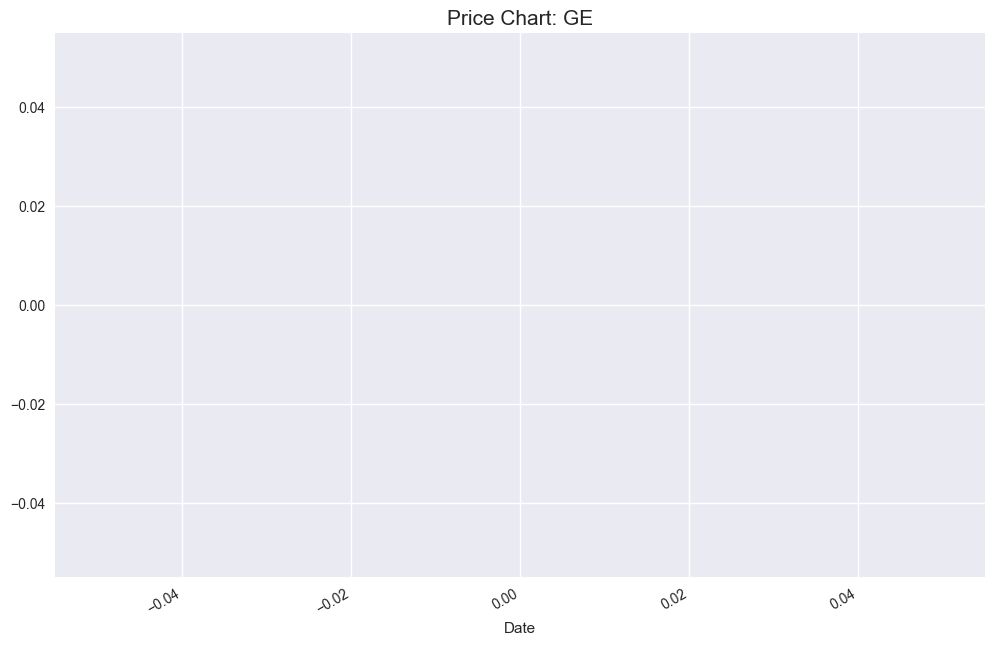

In [107]:
stock.plot_prices()

In [108]:
class FinancialInstrument():
    def __init__(self, ticker, start, end):
        self._ticker = ticker
        self.start = start
        self.end = end
        self.get_data()
        self.log_returns()
    
    def __repr__(self): 
        return "FinancialInstrument(ticker = {}, start = {}, end = {})".format(self._ticker, 
                                                                               self.start, self.end)
    def get_data(self):
        raw = yf.download(self._ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
        raw.rename(columns = {"Close":"price"}, inplace = True)
        self.data = raw
        
    def log_returns(self):
        self.data["log_returns"] = np.log(self.data.price/self.data.price.shift(1))
        
    def plot_prices(self):
        self.data.price.plot(figsize = (12, 8))
        plt.title("Price Chart: {}".format(self._ticker), fontsize = 15)
    
    def plot_returns(self, kind = "ts"):
        if kind == "ts":
            self.data.log_returns.plot(figsize = (12, 8))
            plt.title("Returns: {}".format(self._ticker), fontsize = 15)
        elif kind == "hist":
            self.data.log_returns.hist(figsize = (12, 8), bins = int(np.sqrt(len(self.data))))
            plt.title("Frequency of Returns: {}".format(self._ticker), fontsize = 15)

In [109]:
stock = FinancialInstrument("aapl", "2015-01-01", "2019-12-31")

C:\Users\bedla\AppData\Local\Temp\ipykernel_14036\3153959918.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(self._ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: CertificateVerifyError('Failed to perform, curl: (60) SSL certificate problem: self signed certificate in certificate chain. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


In [110]:
stock

FinancialInstrument(ticker = aapl, start = 2015-01-01, end = 2019-12-31)

In [111]:
stock.ticker

AttributeError: 'FinancialInstrument' object has no attribute 'ticker'

In [112]:
stock.

SyntaxError: invalid syntax (1863568528.py, line 1)

In [113]:
stock._ticker

'aapl'

## The method set_ticker()

In [114]:
class FinancialInstrument():
    def __init__(self, ticker, start, end):
        self._ticker = ticker
        self.start = start
        self.end = end
        self.get_data()
        self.log_returns()
    
    def __repr__(self): 
        return "FinancialInstrument(ticker = {}, start = {}, end = {})".format(self._ticker, 
                                                                               self.start, self.end)
    def get_data(self):
        raw = yf.download(self._ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
        raw.rename(columns = {"Close":"price"}, inplace = True)
        self.data = raw
        
    def log_returns(self):
        self.data["log_returns"] = np.log(self.data.price/self.data.price.shift(1))
        
    def plot_prices(self):
        self.data.price.plot(figsize = (12, 8))
        plt.title("Price Chart: {}".format(self._ticker), fontsize = 15)
    
    def plot_returns(self, kind = "ts"):
        if kind == "ts":
            self.data.log_returns.plot(figsize = (12, 8))
            plt.title("Returns: {}".format(self._ticker), fontsize = 15)
        elif kind == "hist":
            self.data.log_returns.hist(figsize = (12, 8), bins = int(np.sqrt(len(self.data))))
            plt.title("Frequency of Returns: {}".format(self._ticker), fontsize = 15)
    
    def set_ticker(self, ticker = None):
        if ticker is not None:
            self._ticker = ticker
            self.get_data()
            self.log_returns()

In [115]:
stock = FinancialInstrument("aapl", "2015-01-01", "2019-12-31")

C:\Users\bedla\AppData\Local\Temp\ipykernel_14036\3794694595.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(self._ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: CertificateVerifyError('Failed to perform, curl: (60) SSL certificate problem: self signed certificate in certificate chain. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


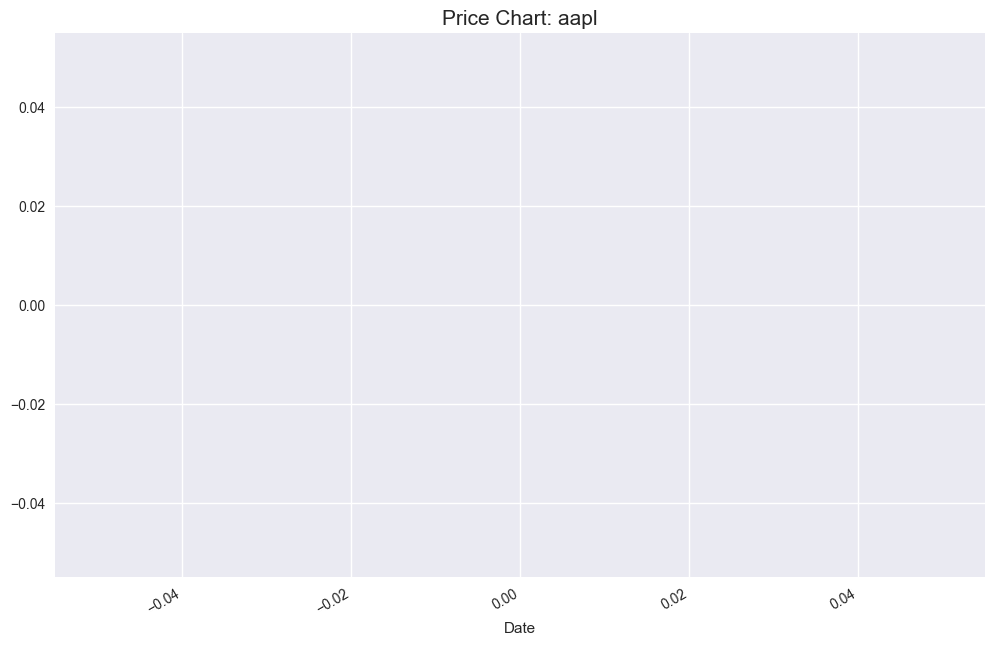

In [116]:
stock.plot_prices()

In [117]:
stock.set_ticker("GE")

C:\Users\bedla\AppData\Local\Temp\ipykernel_14036\3794694595.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(self._ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['GE']: CertificateVerifyError('Failed to perform, curl: (60) SSL certificate problem: self signed certificate in certificate chain. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


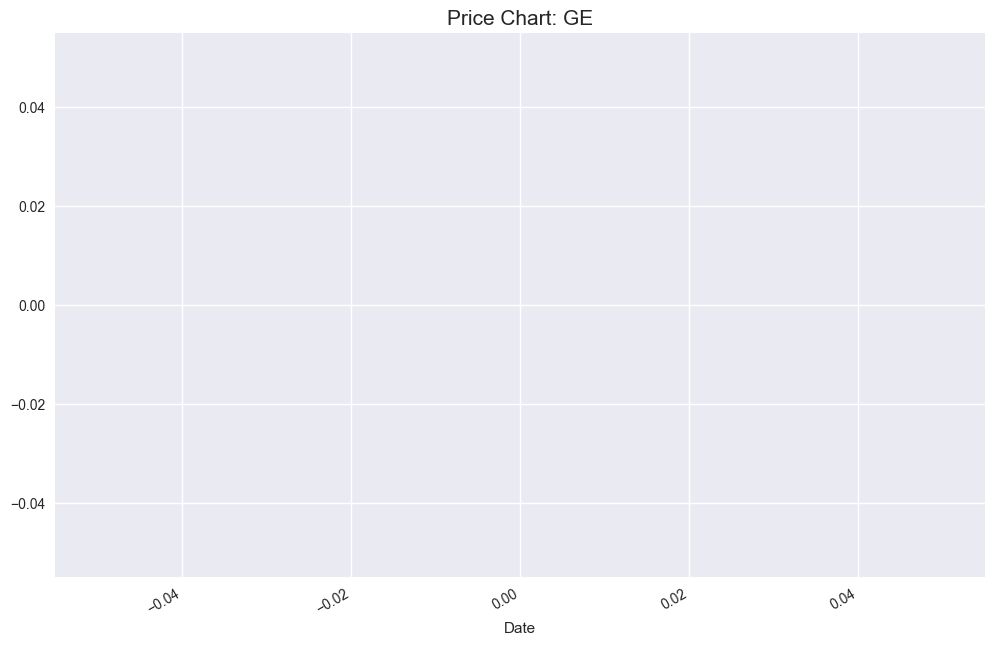

In [118]:
stock.plot_prices()

## Adding more methods and performance metrics

In [119]:
class FinancialInstrument():
    def __init__(self, ticker, start, end):
        self._ticker = ticker
        self.start = start
        self.end = end
        self.get_data()
        self.log_returns()
    
    def __repr__(self): 
        return "FinancialInstrument(ticker = {}, start = {}, end = {})".format(self._ticker, 
                                                                               self.start, self.end)
    def get_data(self):
        raw = yf.download(self._ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
        raw.rename(columns = {"Close":"price"}, inplace = True)
        self.data = raw
        
    def log_returns(self):
        self.data["log_returns"] = np.log(self.data.price/self.data.price.shift(1))
        
    def plot_prices(self):
        self.data.price.plot(figsize = (12, 8))
        plt.title("Price Chart: {}".format(self._ticker), fontsize = 15)
    
    def plot_returns(self, kind = "ts"):
        if kind == "ts":
            self.data.log_returns.plot(figsize = (12, 8))
            plt.title("Returns: {}".format(self._ticker), fontsize = 15)
        elif kind == "hist":
            self.data.log_returns.hist(figsize = (12, 8), bins = int(np.sqrt(len(self.data))))
            plt.title("Frequency of Returns: {}".format(self._ticker), fontsize = 15)
    
    def set_ticker(self, ticker = None):
        if ticker is not None:
            self._ticker = ticker
            self.get_data()
            self.log_returns()
            
    def mean_return(self, freq = None):
        if freq is None:
            return self.data.log_returns.mean()
        else:
            resampled_price = self.data.price.resample(freq).last()
            resampled_returns = np.log(resampled_price / resampled_price.shift(1))
            return resampled_returns.mean()
    
    def std_returns(self, freq = None):
        if freq is None:
            return self.data.log_returns.std()
        else:
            resampled_price = self.data.price.resample(freq).last()
            resampled_returns = np.log(resampled_price / resampled_price.shift(1))
            return resampled_returns.std()
        
    def annualized_perf(self):
        mean_return = round(self.data.log_returns.mean() * 252, 3)
        risk = round(self.data.log_returns.std() * np.sqrt(252), 3)
        print("Return: {} | Risk: {}".format(mean_return, risk))

In [120]:
stock = FinancialInstrument("aapl", "2015-01-01", "2019-12-31")

C:\Users\bedla\AppData\Local\Temp\ipykernel_14036\81312120.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw = yf.download(self._ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: CertificateVerifyError('Failed to perform, curl: (60) SSL certificate problem: self signed certificate in certificate chain. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


In [ ]:
stock.mean_return()

In [ ]:
stock.mean_return("W") # NEW - replace w by W

In [ ]:
stock.std_returns()

In [ ]:
stock.std_returns("YE") # NEW - replace a by YE

In [ ]:
stock.annualized_perf()

## Inheritance

In [ ]:
class FinancialInstrumentBase(): # Parent
    def __init__(self, ticker, start, end):
        self._ticker = ticker
        self.start = start
        self.end = end
        self.get_data()
        self.log_returns()
    
    def __repr__(self): 
        return "FinancialInstrument(ticker = {}, start = {}, end = {})".format(self._ticker, 
                                                                               self.start, self.end)
    def get_data(self):
        raw = yf.download(self._ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
        raw.rename(columns = {"Close":"price"}, inplace = True)
        self.data = raw
        
    def log_returns(self):
        self.data["log_returns"] = np.log(self.data.price/self.data.price.shift(1))
        
    def plot_prices(self):
        self.data.price.plot(figsize = (12, 8))
        plt.title("Price Chart: {}".format(self._ticker), fontsize = 15)
    
    def plot_returns(self, kind = "ts"):
        if kind == "ts":
            self.data.log_returns.plot(figsize = (12, 8))
            plt.title("Returns: {}".format(self._ticker), fontsize = 15)
        elif kind == "hist":
            self.data.log_returns.hist(figsize = (12, 8), bins = int(np.sqrt(len(self.data))))
            plt.title("Frequency of Returns: {}".format(self._ticker), fontsize = 15)
    
    def set_ticker(self, ticker = None):
        if ticker is not None:
            self._ticker = ticker
            self.get_data()
            self.log_returns()

In [ ]:
class RiskReturn(FinancialInstrumentBase): # Child
    
    def __repr__(self): 
        return "RiskReturn(ticker = {}, start = {}, end = {})".format(self._ticker, 
                                                                          self.start, self.end)
    def mean_return(self, freq = None):
        if freq is None:
            return self.data.log_returns.mean()
        else:
            resampled_price = self.data.price.resample(freq).last()
            resampled_returns = np.log(resampled_price / resampled_price.shift(1))
            return resampled_returns.mean()
    
    def std_returns(self, freq = None):
        if freq is None:
            return self.data.log_returns.std()
        else:
            resampled_price = self.data.price.resample(freq).last()
            resampled_returns = np.log(resampled_price / resampled_price.shift(1))
            return resampled_returns.std()
        
    def annualized_perf(self):
        mean_return = round(self.data.log_returns.mean() * 252, 3)
        risk = round(self.data.log_returns.std() * np.sqrt(252), 3)
        print("Return: {} | Risk: {}".format(mean_return, risk))

In [ ]:
stock = RiskReturn("aapl", "2015-01-01", "2019-12-31")

In [ ]:
stock.annualized_perf()

In [ ]:
stock.data

In [ ]:
stock.plot_prices()

In [ ]:
stock.set_ticker("ge")

In [ ]:
stock

In [ ]:
stock.mean_return("W") # NEW - replace w by W

## Inheritance and the super() Function

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
plt.style.use("seaborn-v0_8")

In [100]:
class FinancialInstrumentBase(): # Parent
    def __init__(self, ticker, start, end):
        self._ticker = ticker
        self.start = start
        self.end = end
        self.get_data()
        self.log_returns()
    
    def __repr__(self): 
        return "FinancialInstrument(ticker = {}, start = {}, end = {})".format(self._ticker, 
                                                                               self.start, self.end)
    def get_data(self):
        raw = yf.download(self._ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
        raw.rename(columns = {"Close":"price"}, inplace = True)
        self.data = raw
        
    def log_returns(self):
        self.data["log_returns"] = np.log(self.data.price/self.data.price.shift(1))
        
    def plot_prices(self):
        self.data.price.plot(figsize = (12, 8))
        plt.title("Price Chart: {}".format(self._ticker), fontsize = 15)
    
    def plot_returns(self, kind = "ts"):
        if kind == "ts":
            self.data.log_returns.plot(figsize = (12, 8))
            plt.title("Returns: {}".format(self._ticker), fontsize = 15)
        elif kind == "hist":
            self.data.log_returns.hist(figsize = (12, 8), bins = int(np.sqrt(len(self.data))))
            plt.title("Frequency of Returns: {}".format(self._ticker), fontsize = 15)
    
    def set_ticker(self, ticker = None):
        if ticker is not None:
            self._ticker = ticker
            self.get_data()
            self.log_returns()

In [101]:
class RiskReturn(FinancialInstrumentBase): # Child
    
    def __init__(self, ticker, start, end, freq = None):
        self.freq = freq
        super().__init__(ticker, start, end)
    
    def __repr__(self): 
        return "RiskReturn(ticker = {}, start = {}, end = {})".format(self._ticker, 
                                                                          self.start, self.end)
    def mean_return(self):
        if self.freq is None:
            return self.data.log_returns.mean()
        else:
            resampled_price = self.data.price.resample(self.freq).last()
            resampled_returns = np.log(resampled_price / resampled_price.shift(1))
            return resampled_returns.mean()
    
    def std_returns(self):
        if self.freq is None:
            return self.data.log_returns.std()
        else:
            resampled_price = self.data.price.resample(self.freq).last()
            resampled_returns = np.log(resampled_price / resampled_price.shift(1))
            return resampled_returns.std()
        
    def annualized_perf(self):
        mean_return = round(self.data.log_returns.mean() * 252, 3)
        risk = round(self.data.log_returns.std() * np.sqrt(252), 3)
        print("Return: {} | Risk: {}".format(mean_return, risk))

In [ ]:
stock = RiskReturn("aapl", "2015-01-01", "2019-12-31", freq = "W")

In [ ]:
stock.freq

In [ ]:
stock._ticker

In [ ]:
stock.data

In [ ]:
stock.plot_prices()

In [ ]:
stock.mean_return()

In [ ]:
stock.annualized_perf()

## Docstrings

In [ ]:
class FinancialInstrument():
    ''' Class to analyze Financial Instruments like stocks
    '''
    def __init__(self, ticker, start, end):
        self._ticker = ticker
        self.start = start
        self.end = end
        self.get_data()
        self.log_returns()
    
    def __repr__(self): 
        return "FinancialInstrument(ticker = {}, start = {}, end = {})".format(self._ticker, 
                                                                               self.start, self.end)
    def get_data(self):
        raw = yf.download(self._ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
        raw.rename(columns = {"Close":"price"}, inplace = True)
        self.data = raw
        
    def log_returns(self):
        self.data["log_returns"] = np.log(self.data.price/self.data.price.shift(1))
        
    def plot_prices(self):
        self.data.price.plot(figsize = (12, 8))
        plt.title("Price Chart: {}".format(self._ticker), fontsize = 15)
    
    def plot_returns(self, kind = "ts"):
        ''' plots log returns either as time series ("ts") or as histogram ("hist")
        '''
        if kind == "ts":
            self.data.log_returns.plot(figsize = (12, 8))
            plt.title("Returns: {}".format(self._ticker), fontsize = 15)
        elif kind == "hist":
            self.data.log_returns.hist(figsize = (12, 8), bins = int(np.sqrt(len(self.data))))
            plt.title("Frequency of Returns: {}".format(self._ticker), fontsize = 15)
    
    def set_ticker(self, ticker = None):
        if ticker is not None:
            self._ticker = ticker
            self.get_data()
            self.log_returns()
            
    def mean_return(self, freq = None):
        if freq is None:
            return self.data.log_returns.mean()
        else:
            resampled_price = self.data.price.resample(freq).last()
            resampled_returns = np.log(resampled_price / resampled_price.shift(1))
            return resampled_returns.mean()
    
    def std_returns(self, freq = None):
        if freq is None:
            return self.data.log_returns.std()
        else:
            resampled_price = self.data.price.resample(freq).last()
            resampled_returns = np.log(resampled_price / resampled_price.shift(1))
            return resampled_returns.std()
        
    def annualized_perf(self):
        mean_return = round(self.data.log_returns.mean() * 252, 3)
        risk = round(self.data.log_returns.std() * np.sqrt(252), 3)
        print("Return: {} | Risk: {}".format(mean_return, risk))

__Final Version__

In [ ]:
class FinancialInstrument():
    ''' Class for analyzing Financial Instruments like stocks.

    Attributes
    ==========
    ticker: str
        ticker symbol with which to work with
    start: str
        start date for data retrieval
    end: str
        end date for data retrieval

    Methods
    =======
    get_data:
        retrieves daily price data (from yahoo finance) and prepares the data
    log_returns:
        calculates log returns
    plot_prices:
        creates a price chart
    plot_returns:
        plots log returns either as time series ("ts") or histogram ("hist")
    set_ticker:
        sets a new ticker
    mean_return:
        calculates mean return
    std_returns:
        calculates the standard deviation of returns (risk)
    annualized_perf:
        calculates annulized return and risk
    '''
    
    def __init__(self, ticker, start, end):
        self._ticker = ticker
        self.start = start
        self.end = end
        self.get_data()
        self.log_returns()
    
    def __repr__(self): 
        return "FinancialInstrument(ticker = {}, start = {}, end = {})".format(self._ticker, 
                                                                               self.start, self.end)
    def get_data(self):
        ''' retrieves (from yahoo finance) and prepares the data
        '''
        raw = yf.download(self._ticker, self.start, self.end, multi_level_index = False).Close.to_frame()
        raw.rename(columns = {"Close":"price"}, inplace = True)
        self.data = raw
        
    def log_returns(self):
        '''calculates log returns
        '''
        self.data["log_returns"] = np.log(self.data.price/self.data.price.shift(1))
        
    def plot_prices(self):
        ''' creates a price chart
        '''
        self.data.price.plot(figsize = (12, 8))
        plt.title("Price Chart: {}".format(self._ticker), fontsize = 15)
    
    def plot_returns(self, kind = "ts"):
        ''' plots log returns either as time series ("ts") or histogram ("hist")
        '''
        if kind == "ts":
            self.data.log_returns.plot(figsize = (12, 8))
            plt.title("Returns: {}".format(self._ticker), fontsize = 15)
        elif kind == "hist":
            self.data.log_returns.hist(figsize = (12, 8), bins = int(np.sqrt(len(self.data))))
            plt.title("Frequency of Returns: {}".format(self._ticker), fontsize = 15)
    
    def set_ticker(self, ticker = None):
        '''sets a new ticker
        '''
        if ticker is not None:
            self._ticker = ticker
            self.get_data()
            self.log_returns()
            
    def mean_return(self, freq = None):
        '''calculates mean return
        '''
        if freq is None:
            return self.data.log_returns.mean()
        else:
            resampled_price = self.data.price.resample(freq).last()
            resampled_returns = np.log(resampled_price / resampled_price.shift(1))
            return resampled_returns.mean()
    
    def std_returns(self, freq = None):
        '''calculates the standard deviation of returns (risk)
        '''
        if freq is None:
            return self.data.log_returns.std()
        else:
            resampled_price = self.data.price.resample(freq).last()
            resampled_returns = np.log(resampled_price / resampled_price.shift(1))
            return resampled_returns.std()
        
    def annualized_perf(self):
        '''calculates annulized return and risk
        '''
        mean_return = round(self.data.log_returns.mean() * 252, 3)
        risk = round(self.data.log_returns.std() * np.sqrt(252), 3)
        print("Return: {} | Risk: {}".format(mean_return, risk))